In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
ds = xr.open_dataset(
    '/data9/G5053/data/danielmw/file.nc.gz.decomp')


ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


In [3]:
ds

<xarray.Dataset> Size: 112MB
Dimensions:      (lat: 90, lon: 180, time: 1730, nv: 2)
Coordinates:
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2024-02-15
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 112MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2024-03-08 11:37:27 by SBBX_to_nc 2.0 - ILAND=1200,...

In [4]:
tmean_unweighted = ds.tempanomaly.mean(dim=('lat','lon'))
tmean_unweighted

<xarray.DataArray 'tempanomaly' (time: 1730)> Size: 7kB
array([-0.23715548, -0.40871722, -0.18538123, ...,  1.512981  ,
        1.0194248 ,  1.6302183 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2024-02-15

In [5]:
weights = np.cos(ds.lat*np.pi/180)
weights

<xarray.DataArray 'lat' (lat: 90)> Size: 360B
array([0.01745238, 0.05233585, 0.0871558 , 0.12186933, 0.15643449,
       0.19080894, 0.22495104, 0.25881895, 0.29237166, 0.32556814,
       0.35836798, 0.3907311 , 0.42261827, 0.45399043, 0.48480958,
       0.5150381 , 0.544639  , 0.57357645, 0.601815  , 0.6293203 ,
       0.65605897, 0.6819983 , 0.70710677, 0.7313537 , 0.7547096 ,
       0.777146  , 0.7986355 , 0.819152  , 0.83867055, 0.8571673 ,
       0.8746197 , 0.8910065 , 0.90630776, 0.92050487, 0.9335804 ,
       0.94551855, 0.9563047 , 0.9659258 , 0.97437006, 0.98162717,
       0.98768836, 0.99254614, 0.9961947 , 0.9986295 , 0.9998477 ,
       0.9998477 , 0.9986295 , 0.9961947 , 0.99254614, 0.98768836,
       0.98162717, 0.97437006, 0.9659258 , 0.9563047 , 0.94551855,
       0.9335804 , 0.92050487, 0.90630776, 0.8910065 , 0.8746197 ,
       0.8571673 , 0.83867055, 0.819152  , 0.7986355 , 0.777146  ,
       0.7547096 , 0.7313537 , 0.70710677, 0.6819983 , 0.65605897,
       0.6293203 , 0.601815  , 0.57357645, 0.544639  , 0.5150381 ,
       0.48480958, 0.45399043, 0.42261827, 0.3907311 , 0.35836798,
       0.32556814, 0.29237166, 0.25881895, 0.22495104, 0.19080894,
       0.15643449, 0.12186933, 0.0871558 , 0.05233585, 0.01745238],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0

In [7]:
tmean_weighted = ds.tempanomaly.weighted(weights).mean(
    dim=('lat','lon'))
tmean_weighted

<xarray.DataArray 'tempanomaly' (time: 1730)> Size: 7kB
array([-0.18755907, -0.27662537, -0.10562596, ...,  1.3526449 ,
        1.2122812 ,  1.4400328 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2024-02-15

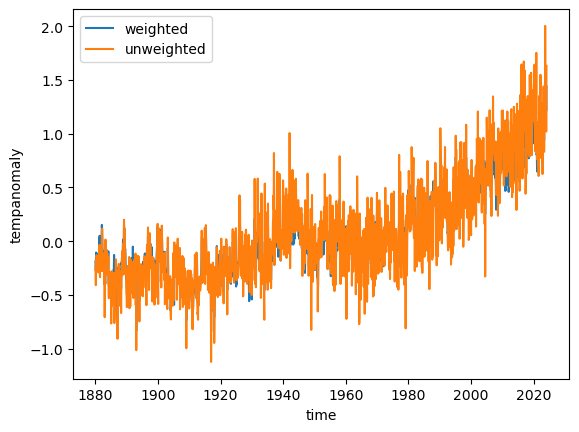

In [8]:
tmean_weighted.plot(label='weighted')
tmean_unweighted.plot(label='unweighted')
plt.legend()

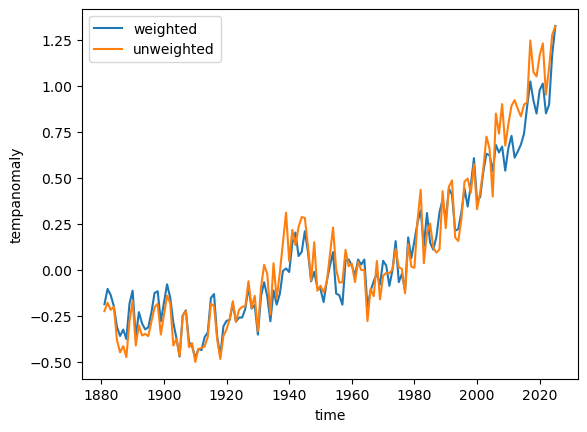

In [10]:
tmean_weighted.resample(time='YE').mean().plot(label='weighted')
tmean_unweighted.resample(time='YE').mean().plot(label='unweighted')
plt.legend()

In [11]:
import cartopy
import cartopy.crs as ccrs

In [12]:
ccrs.PlateCarree()

<Projected CRS: +proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (unknown)
- N[north]: Northing (unknown)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Equidistant Cylindrical
Datum: Unknown based on WGS 84 ellipsoid
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

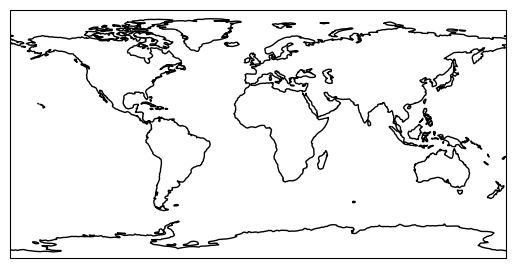

In [13]:
plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

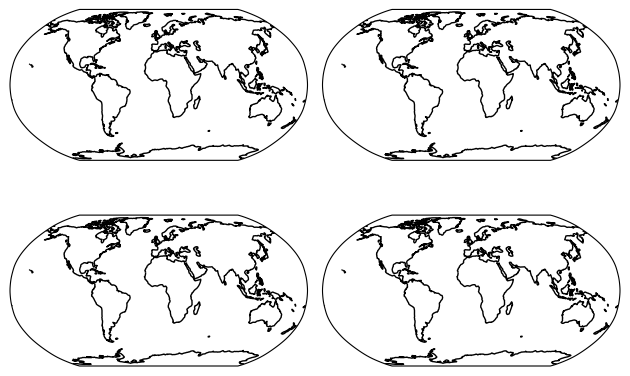

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=2,
                         subplot_kw={'projection':ccrs.Robinson()
                                    })

axes[0,0].coastlines()
axes[1,0].coastlines()
axes[0,1].coastlines()
axes[1,1].coastlines()

plt.tight_layout()

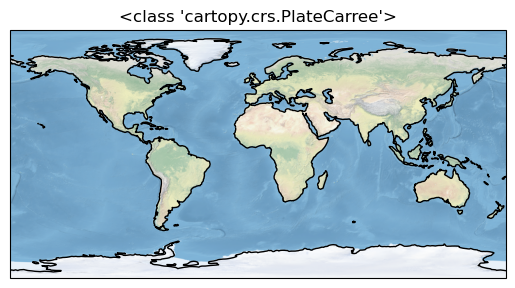

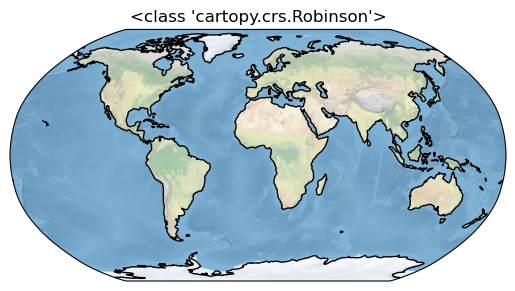

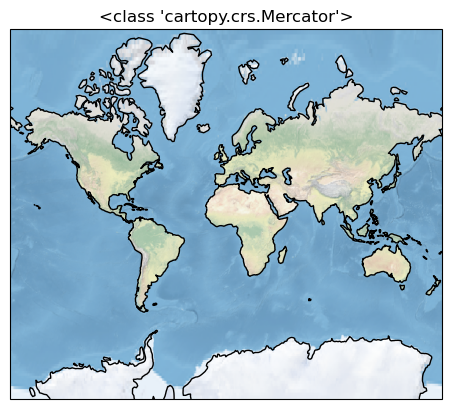

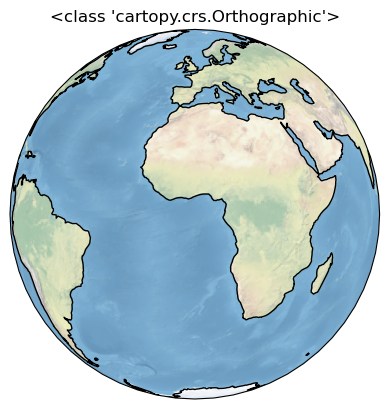

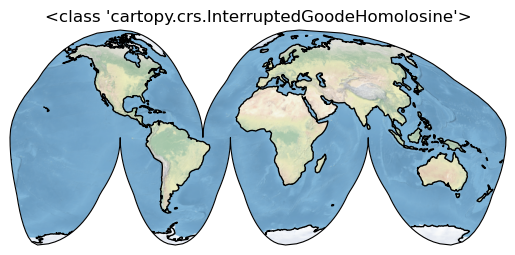

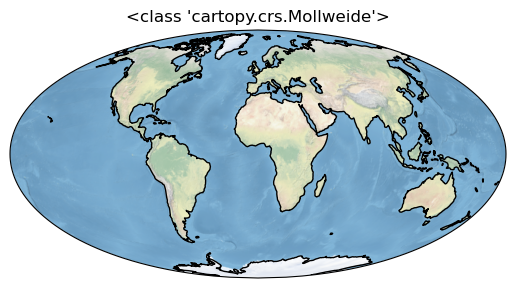

In [18]:
projections = [ccrs.PlateCarree(), 
               ccrs.Robinson(),
               ccrs.Mercator(),
               ccrs.Orthographic(),
               ccrs.InterruptedGoodeHomolosine(), 
               ccrs.Mollweide()
              ]

for proj in projections: 
    plt.figure()
    ax = plt.axes(projection=proj)
    ax.stock_img()
    ax.coastlines()
    ax.set_title(f'{type(proj)}')

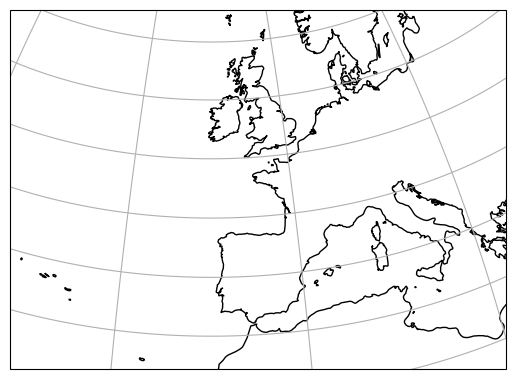

In [25]:
central_lon, central_lat = -10, 45
extent = [-30, 20, 30, 60]
ax = plt.axes(projection=ccrs.Orthographic(
    central_lon,central_lat))
ax.set_extent(extent)
ax.gridlines()
ax.coastlines(resolution='50m')

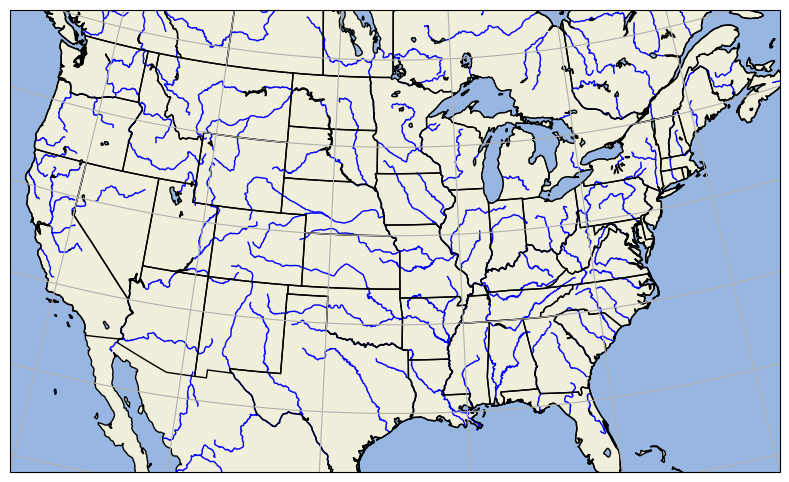

In [30]:
extent = [-120, -70, 24, 51]
central_lon = np.mean(extent[0:2])
central_lat = np.mean(extent[2:])

rivers_10m = cartopy.feature.NaturalEarthFeature(
    'physical', 'rivers_lake_centerlines','10m')

plt.figure(figsize=(12,6)) 
ax=plt.axes(projection=ccrs.AlbersEqualArea(central_lon, 
                                            central_lat))
ax.set_extent(extent) 
#ax.coastlines()
ax.add_feature(cartopy.feature.OCEAN)
#ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(rivers_10m, facecolor='None',edgecolor='b')
ax.add_feature(cartopy.feature.LAND, edgecolor='k')
ax.add_feature(cartopy.feature.STATES, edgecolor='k')
ax.add_feature(cartopy.feature.LAKES, edgecolor='k')
ax.gridlines()



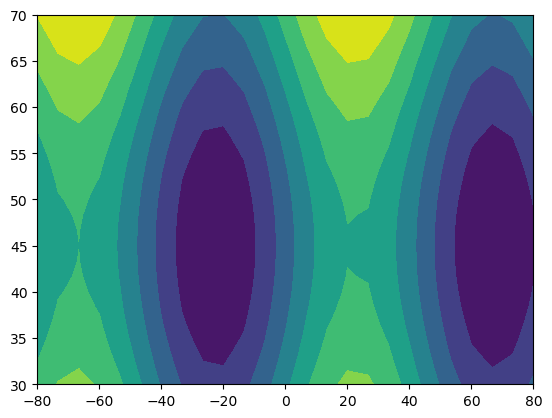

In [31]:
lon = np.linspace(-80,80,25)
lat = np.linspace(30,70,25)
lon2d, lat2d = np.meshgrid(lon,lat)
data = np.cos(np.deg2rad(lat2d)*4) + np.sin(np.deg2rad(lon2d)*4)
plt.contourf(lon2d,lat2d, data)

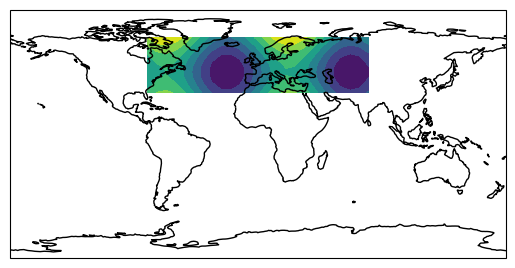

In [35]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.contourf(lon, lat, data)
ax.set_global()

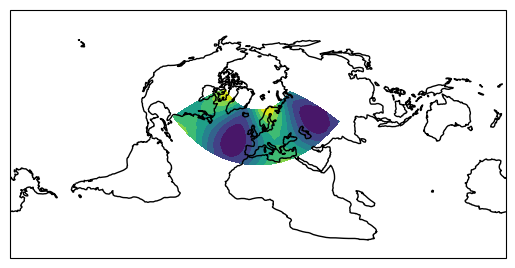

In [38]:
projection = ccrs.RotatedPole(pole_longitude=-177.5, 
                              pole_latitude=37.5)
ax = plt.axes(projection=projection)
ax.coastlines()
ax.set_global()
ax.contourf(lon, lat, data,transform=ccrs.PlateCarree())

In [40]:
ds = xr.open_dataset('/data9/G5053/data/shr/sst.mnmean.nc',
                    drop_variables='time_bnds')
ds

<xarray.Dataset> Size: 131MB
Dimensions:  (lat: 89, lon: 180, time: 2042)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 16kB 1854-01-01 1854-02-01 ... 2024-02-01
Data variables:
    sst      (time, lat, lon) float32 131MB ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2024-03-03

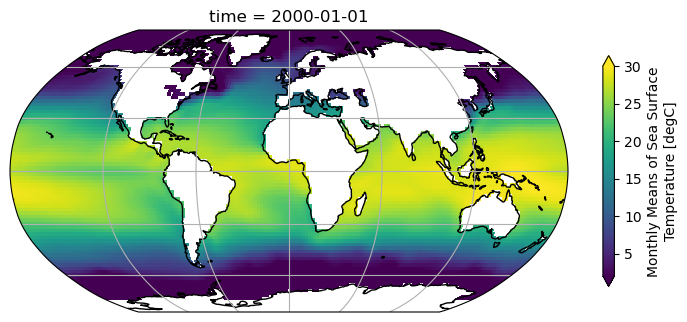

In [42]:
sst = ds.sst.sel(time='2000-01-01')
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines()
ax.gridlines()
sst.plot(axes=ax, transform=ccrs.PlateCarree(), vmin=2, 
         vmax=30, cbar_kwargs={'shrink':0.5})

In [43]:
ds = xr.open_dataset(
    '/data9/G5053/data/danielmw/file.nc.gz.decomp')


In [46]:
temp1 = ds.tempanomaly.sel(time=slice('1880-01-01',
                                      '1890-01-01')).mean(dim='time')
temp2 = ds.tempanomaly.sel(time=slice('2014-01-01',
                                      '2024-01-01')).mean(dim='time')
temp2
temps = [temp1, temp2, temp2-temp1]
labels = ['1880s','2014-2024','difference']

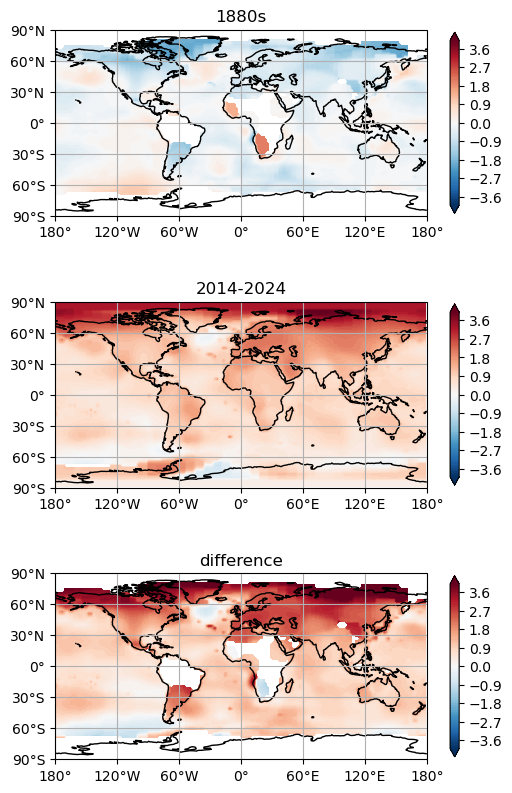

In [49]:
import cartopy.mpl.ticker as cticker

fig,axs = plt.subplots(nrows=3, ncols=1, figsize=(6,10),
            subplot_kw={'projection':ccrs.PlateCarree()}
                      )
clevels = np.arange(-4,4.01,0.1)

for i, label in enumerate(labels):
    cs = axs[i].contourf(ds.lon, ds.lat, temps[i], clevels, 
                         transform=ccrs.PlateCarree(), 
                         cmap='RdBu_r', extend='both')
    axs[i].coastlines()
    axs[i].gridlines()
    axs[i].set_title(label)
    fig.colorbar(cs, ax=axs[i],shrink=0.8)

    axs[i].set_xticks(np.arange(-180,181, 60), 
                      crs=ccrs.PlateCarree())
    axs[i].xaxis.set_major_formatter(cticker.LongitudeFormatter())


    axs[i].set_yticks(np.arange(-90,91, 30), 
                      crs=ccrs.PlateCarree())
    axs[i].yaxis.set_major_formatter(cticker.LatitudeFormatter())
